# Jacobian Lens Explorer

Thrust 2 of `notes/scholarlm/threads/Jacobian Lens.md`: visualize a single
example's Jacobian-lens j-score matrix `S_e`, persisted by Thrust 1
(`experiments/run_jacobian_lens.py` / `JacobianLensLM`) as
`jacobian_scores.npz`. Purely read-only against that artifact — no model or
GPU load, only a plain tokenizer for View 2.

Setup: `uv sync --extra dev --extra viz` (matplotlib lives in `viz`, not
`dev`). View 2's tokenizer load additionally requires the gated
`meta-llama/Llama-3.1-8B` repo's config/tokenizer files to already be
present under `$HF_CACHE` (exact-case dir `models--meta-llama--Llama-3.1-8B`)
— e.g. via `hf download "meta-llama/Llama-3.1-8B" --include "*.json"
"tokenizer*" --cache-dir "$HF_CACHE"` after accepting the model's license on
huggingface.co.

In [1]:
import html
import os
import sys
from pathlib import Path

_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / "pyproject.toml").exists() and _REPO_ROOT != _REPO_ROOT.parent:
    _REPO_ROOT = _REPO_ROOT.parent

for _p in (str(_REPO_ROOT), str(_REPO_ROOT / "src"), str(_REPO_ROOT / "experiments")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

# Dataset configs store paths (e.g. metadata_file) relative to the repo root,
# and nbconvert/Jupyter otherwise runs cells from the notebook's own directory
# (examples/) — chdir so those relative paths resolve regardless of where this
# notebook was launched from.
os.chdir(_REPO_ROOT)

import contextlib
import io

import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from IPython.display import HTML, display

import paths
import judge_common
from run_extraction import load_dataset_config
from model_registry import JACOBIAN_LENS_REGISTRY
from scholarlm.jacobianlenslm import tokenize
from analysis.loaders import load_extraction

## Parameters

`lens_model` only has one valid value today (`llama-3.1-8b-base` — the only
key in `JACOBIAN_LENS_REGISTRY` with a pretrained lens on HF), but these are
left as real variables rather than inlined literals so a second lens later
needs no rework here.

In [2]:
dataset = "pond"
extraction_model = "gemma-3-27b"
extraction_date = "2026_05_05"
lens_model = "llama-3.1-8b-base"
lens_date = "2026_08_06_gpu_smoketest3"

# Max number of preceding tokens averaged into each token's baseline (see
# "Diff transform" below). window=1 reproduces plain adjacent-token diffing.
diff_window = 50

## Load the j-score matrices

`paths.jacobian_lens(...)`'s `date` arg defaults to *today* if omitted —
always pass `lens_date` explicitly, or this silently resolves to a
nonexistent directory on any day other than the run's own date.

In [3]:
scores_dir = paths.jacobian_lens(dataset, extraction_model, extraction_date, lens_model, lens_date)
scores_path = scores_dir / "jacobian_scores.npz"
npz = np.load(scores_path, allow_pickle=True)

layer_indices = npz["layer_indices"]
# Sort numerically (key=int) — plain lexicographic sort would put "10" before "2".
measurement_ids = sorted((k for k in npz.files if k != "layer_indices"), key=int)
print(f"{scores_path}\n{len(measurement_ids)} examples, {len(layer_indices)} layers "
      f"({layer_indices.min()}..{layer_indices.max()})")

/projectnb/mcnet/kevin/coastal/scholarlm/data/experiments/pond/jacobian_lens/gemma-3-27b/2026_05_05/llama-3.1-8b-base/2026_08_06_gpu_smoketest3/jacobian_scores.npz
200 examples, 31 layers (0..30)


## Reconstruct each example's (instructions, context, query)

Same construction `run_jacobian_lens.py` used to build the prompts Thrust 1
scored: `judge_common.load_documents_for_dataset` +
`judge_common.prepare_chat_entries` over the extraction's `final.json`.
`prepare_chat_entries` builds one entry per input record — the npz only has
`len(measurement_ids)` examples because `run_jacobian_lens.py` was run with
`--limit {len(measurement_ids)}`, so truncate `final.json` the same way
before calling it (passing the full ~2900-record file both wastes time and
floods this notebook with `judge_common`'s per-paper debug prints).

In [4]:
dataset_config = load_dataset_config(dataset)
final = load_extraction(dataset, extraction_model, extraction_date)
final = final[: len(measurement_ids)]

ocr_dir = str(Path(dataset_config.data_dir) / "ocr_output_raw")
# judge_common prints a full-page DEBUG dump for the first few papers it processes;
# suppress it here rather than let it flood the saved notebook output.
with contextlib.redirect_stdout(io.StringIO()):
    documents = judge_common.load_documents_for_dataset(dataset_config, ocr_dir)
    chat_entries = judge_common.prepare_chat_entries(final, documents, dataset_config)

# Look up by measurement_id, not list index — custom_id is prepare_chat_entries'
# original-index-into-`final`, which only happens to equal measurement_id here.
final_by_mid = {str(final[int(e["custom_id"])]["measurement_id"]): e for e in chat_entries}
record_by_mid = {str(r["measurement_id"]): r for r in final}
print(f"{len(chat_entries)} chat entries built from {len(final)} truncated records")

200 chat entries built from 200 truncated records


## Tokenizer (for View 2 only — no model/GPU load)

In [5]:
model_cfg = JACOBIAN_LENS_REGISTRY[lens_model]
tokenizer = AutoTokenizer.from_pretrained(
    model_cfg["model_id"],
    cache_dir=os.environ.get("HF_CACHE"),
    local_files_only=True,
)
use_chat_template = model_cfg.get("use_chat_template", False)
print(f"Loaded tokenizer for {model_cfg['model_id']!r} (vocab_size={tokenizer.vocab_size})")

Loaded tokenizer for 'meta-llama/Llama-3.1-8B' (vocab_size=128000)


## Diff transform

`ŝ_{l,j} = s_{l,j+1} - mean(s_{l, max(0, j+1-window) : j+1])`: token `j+1`'s
score minus the average of up to `window` tokens immediately preceding it
(not including itself). `window=1` reproduces plain adjacent-token diffing
(`ŝ_{l,j} = s_{l,j+1} - s_{l,j}`, equivalent to `np.diff`) as a special
case. A wider window trades token-to-token jitter for a smoother baseline —
each anomalous token then produces one spike against its local context
average rather than the two canceling edges (in, then back out) adjacent-diff
produces. Vectorized via a prefix-sum, not a Python loop over columns.

In [6]:
def windowed_baseline_diff(S: np.ndarray, window: int) -> np.ndarray:
    """S_hat[l, j] = S[l, j+1] - mean(S[l, max(0, j+1-window):j+1]), j = 0..n-2."""
    n_layers, n_tokens = S.shape
    cumsum = np.concatenate([np.zeros((n_layers, 1)), np.cumsum(S, axis=1)], axis=1)
    idx_end = np.arange(1, n_tokens)
    idx_start = np.maximum(0, idx_end - window)
    counts = idx_end - idx_start
    baseline = (cumsum[:, idx_end] - cumsum[:, idx_start]) / counts
    return S[:, 1:] - baseline

## Pick an example

`example_index` is a plain integer index into `measurement_ids` (sorted
numerically) — edit and re-run this cell to look at a different example.

In [7]:
example_index = 0
mid = measurement_ids[example_index]
S_e = npz[mid]  # shape (n_source_layers, n_context_tokens)
S_hat_e = windowed_baseline_diff(S_e, diff_window)  # shape (n_source_layers, n_context_tokens - 1)
print(f"example_index={example_index} -> measurement_id={mid!r}, S_e.shape={S_e.shape}, diff_window={diff_window}")

example_index=0 -> measurement_id='0', S_e.shape=(31, 1543), diff_window=50


## View 1 — overview: token-diffed matrix `Ŝ_e`

Diverging colormap centered at 0, normalized by this matrix's own max
absolute value.

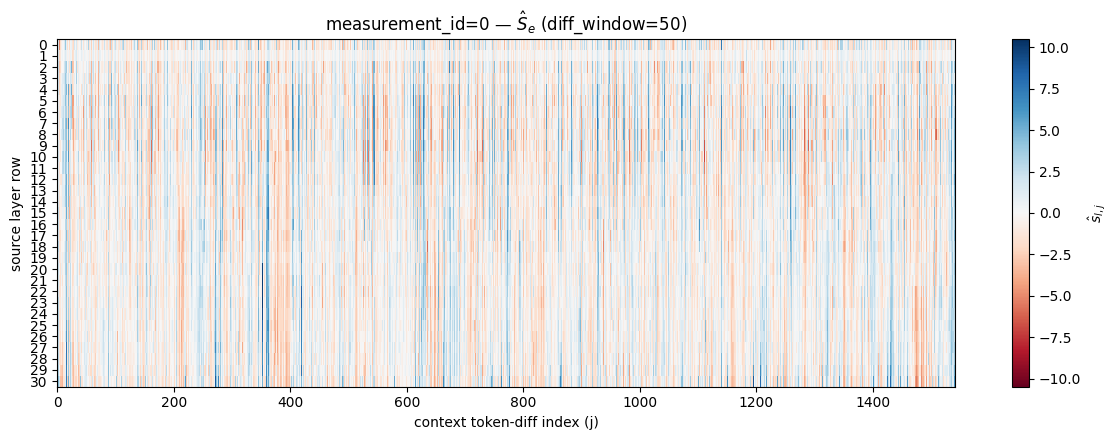

In [8]:
m = np.abs(S_hat_e).max()
fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.matshow(S_hat_e, cmap="RdBu", vmin=-m, vmax=m, aspect="auto")
ax.set_xlabel("context token-diff index (j)")
ax.set_ylabel("source layer row")
ax.set_yticks(range(len(layer_indices)))
ax.set_yticklabels(layer_indices)
ax.xaxis.set_ticks_position("bottom")
fig.colorbar(im, ax=ax, label=r"$\hat{s}_{l,j}$")
ax.set_title(f"measurement_id={mid} — $\\hat{{S}}_e$ (diff_window={diff_window})")
fig.tight_layout()
plt.show()

## View 2 — per-layer detail

Pick a single row (layer) of `Ŝ_e` via `layer_row` (an index into
`layer_indices` / rows of `S_hat_e`, not a raw model layer number — read off
`layer_indices[layer_row]` for the actual layer). Context tokens are colored
by that row's own diffs, normalized by *that row's* max absolute value (not
the global `m` from View 1): negative shades toward red, positive toward
blue, white at/near 0. `ŝ_{l,j}` (diff index `j`) colors context token
`j + 1`; the first context token has no preceding diff and is left
uncolored.

Deviates from the design thread (`Jacobian Lens.md`), which specifies a
plain white→blue scale with no negative/red handling — kept diverging here
for consistency with View 1, which is also diff-based and signed. Revisit
if that turns out to read worse in practice.

In [17]:
layer_row = 16  # index into layer_indices, not a raw layer number

entry = final_by_mid[mid]
record = record_by_mid[mid]

input_ids, instruction_idx, context_idx, query_idx = tokenize(
    entry["system"], entry["page_text"], entry["user_query"],
    tokenizer, use_chat_template=use_chat_template,
)
assert len(context_idx) == S_e.shape[1], (
    f"context token count ({len(context_idx)}) != S_e columns ({S_e.shape[1]}) "
    "— retokenization no longer matches the persisted score matrix."
)

diffs = S_hat_e[layer_row]
row_m = np.abs(diffs).max() if diffs.size else 0.0
token_strs = [tokenizer.decode([input_ids[i]]) for i in context_idx]


def _diverging_color(v: float, scale: float, blue=(37, 99, 235), red=(220, 38, 38)) -> str:
    t = 0.0 if scale == 0 else max(-1.0, min(1.0, v / scale))
    base = blue if t >= 0 else red
    t = abs(t)
    rgb = tuple(int(round(255 + t * (c - 255))) for c in base)
    return f"rgb({rgb[0]},{rgb[1]},{rgb[2]})"


spans = []
for k, tok_str in enumerate(token_strs):
    color = "rgb(255,255,255)" if k == 0 else _diverging_color(diffs[k - 1], row_m)
    spans.append(f'<span style="background-color:{color}">{html.escape(tok_str)}</span>')

context_html = (
    '<div style="font-family: ui-monospace, monospace; white-space: pre-wrap; '
    'line-height: 1.7; border: 1px solid #999; padding: 10px; color: #111;">'
    + "".join(spans) + "</div>"
)

measurement_fields = [
    "name", "entity_id", "attribute", "attribute_terms", "date",
    "additional_details", "value", "units", "source", "document_id",
    "page_number", "measurement_id",
]
print(f"measurement_id={mid}  |  layer {layer_indices[layer_row]} (row {layer_row})")
for field in measurement_fields:
    if field in record:
        print(f"  {field}: {record[field]}")

display(HTML(context_html))

measurement_id=0  |  layer 16 (row 16)
  name: agricultural pond
  entity_id: doc_0_entity_0
  attribute: surface_area
  attribute_terms: ['ha']
  date: 2016
  additional_details: October–December, temperate agricultural pond in central Maryland, United States
  value: 0.26
  units: ha
  source: ['text']
  document_id: agricultural_freshwater
  page_number: [1]
  measurement_id: 0


Top context tokens by `|ŝ_{l,j}|` at this layer — a quick numeric sanity
check alongside the rendered colors above: are the highest-magnitude tokens
plausibly related to the measurement being validated?

In [10]:
order = np.argsort(-np.abs(diffs))[:15]
for j in order:
    print(f"  token[{j + 1}]={token_strs[j + 1]!r:<20} diff={diffs[j]:+.4f}")

  token[363]='ap'                 diff=+6.8738
  token[405]='ann'                diff=+6.3434
  token[1103]='anc'                diff=+6.2820
  token[347]='ap'                 diff=+5.8460
  token[632]='ind'                diff=+5.7588
  token[406]='are'                diff=+5.5226
  token[371]='Newton'             diff=-5.4248
  token[362]='ph'                 diff=+5.1580
  token[361]='Al'                 diff=+5.1425
  token[1396]='D'                  diff=+4.9931
  token[282]='Cl'                 diff=+4.9664
  token[319]=' Newton'            diff=-4.9627
  token[773]=' vir'               diff=+4.9332
  token[155]='nder'               diff=+4.9119
  token[528]='199'                diff=+4.8852
